## Real Stock Portfolio Optimization (QAOA Mixer Comparison)

This notebook uses **real market data** to compare the package's two QAOA mixer options on the same portfolio-selection problem.

### Focus

Unlike the Binary VQE example, this notebook is about **algorithm behavior**: how the standard X mixer and the XY mixer differ in the same real-data setting.

### Pipeline

1. Download adjusted prices for a small equity universe.
2. Estimate annualized expected returns $\mu$ and covariance $\Sigma$.
3. Run QAOA twice with the same hyperparameters but different mixers.
4. Compare cost traces, marginal inclusion probabilities, and final Top-K selections.

### Requirements

```bash
pip install "vqe-portfolio[data]"
```


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from vqe_portfolio import get_stock_data, run_qaoa
from vqe_portfolio.plotting import bar_allocations
from vqe_portfolio.types import QAOAConfig
from vqe_portfolio.utils import resolve_notebook_outdir, set_global_seed

SEED = 0
set_global_seed(SEED)

OUTDIR = resolve_notebook_outdir()

## Data configuration

In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "AMZN"]
start = "2024-01-01"
end = "2025-01-01"

mu_s, Sigma_df, prices = get_stock_data(
    tickers,
    start=start,
    end=end,
    auto_adjust=True,
    use_log=True,
    shrink="lw",
    scale="none",
)

mu = np.array(mu_s.loc[tickers].values, dtype=float)
Sigma = np.array(Sigma_df.loc[tickers, tickers].values, dtype=float)

print("Tickers:", tickers)
print("Annualized mu:")
for t, m in zip(tickers, mu):
    print(f"  {t}: {float(m): .6f}")
print("\nSigma (annualized) shape:", Sigma.shape)
print("Prices rows:", prices.shape[0])

Tickers: ['AAPL', 'MSFT', 'NVDA', 'AMZN']
Annualized mu:
  AAPL:  0.294857
  MSFT:  0.131251
  NVDA:  0.994034
  AMZN:  0.368969

Sigma (annualized) shape: (4, 4)
Prices rows: 261


## Helper functions

In [3]:
def objective_value(
    x: np.ndarray,
    mu: np.ndarray,
    Sigma: np.ndarray,
    lam: float,
    alpha: float,
    k: int,
) -> float:
    x = np.asarray(x, dtype=float)
    return float(lam * x @ Sigma @ x - mu @ x + alpha * (x.sum() - k) ** 2)


def summarize_result(name: str, res, lam: float, alpha: float, k: int) -> None:
    print(name)
    print("-" * len(name))
    print("gammas:", np.asarray(res.gammas))
    print("betas :", np.asarray(res.betas))
    print("x_prob:", np.asarray(res.x_prob))
    print("x_topk:", np.asarray(res.x_topk))
    print("x_mode:", np.asarray(res.x_mode))
    if res.x_best_feasible is None:
        print("x_best_feasible: None")
    else:
        x_best = np.asarray(res.x_best_feasible, dtype=int)
        obj = objective_value(x_best, mu, Sigma, lam=lam, alpha=alpha, k=k)
        print("x_best_feasible:", x_best, f"(objective={obj:.6f})")
    print()

## Run QAOA with two mixers

In [4]:
K = 2
LAM = 3.0
ALPHA = 8.0

common = dict(
    p=2,
    steps=50,
    stepsize=0.15,
    log_every=10,
    shots_train=None,
    shots_sample=1000,
    lam=LAM,
    alpha=ALPHA,
    k=K,
    seed=SEED,
    device="default.qubit",
)

cfg_x = QAOAConfig(mixer="x", **common)
cfg_xy = QAOAConfig(mixer="xy", **common)

res_x = run_qaoa(mu=mu, Sigma=Sigma, cfg=cfg_x)
res_xy = run_qaoa(mu=mu, Sigma=Sigma, cfg=cfg_xy)

summarize_result("QAOA with X mixer", res_x, lam=LAM, alpha=ALPHA, k=K)
summarize_result("QAOA with XY mixer", res_xy, lam=LAM, alpha=ALPHA, k=K)

QAOA with X mixer
-----------------
gammas: [1.61444202 3.25892614]
betas : [1.32113196 1.43924444]
x_prob: [0.52824068 0.46511455 0.49475116 0.48524149]
x_topk: [1 0 1 0]
x_mode: [1 0 1 0]
x_best_feasible: [1 0 1 0] (objective=-0.205324)

QAOA with XY mixer
------------------
gammas: [ 1.86247652 10.63019404]
betas : [2.5643274  2.71605825]
x_prob: [0.70033544 0.39632846 0.60367154 0.29966456]
x_topk: [1 0 1 0]
x_mode: [1 0 1 0]
x_best_feasible: [1 0 1 0] (objective=-0.205324)



## Convergence comparison

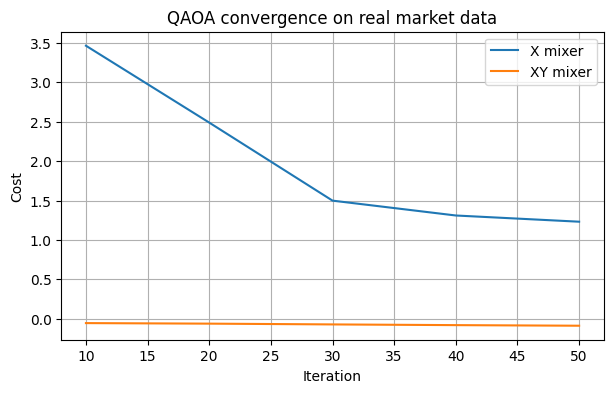

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(res_x.cost_trace.steps, res_x.cost_trace.values, label="X mixer")
plt.plot(res_xy.cost_trace.steps, res_xy.cost_trace.values, label="XY mixer")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("QAOA convergence on real market data")
plt.grid(True)
plt.legend()
plt.savefig(
    OUTDIR / "QAOA_Mixer_Comparison_Convergence_Real_Example_03.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Probability comparison

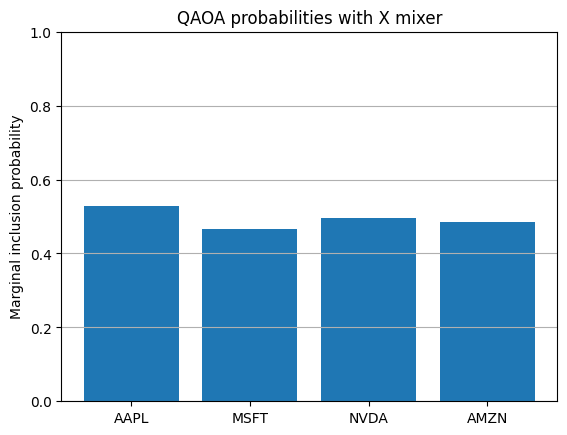

In [6]:
bar_allocations(
    tickers,
    np.array(res_x.x_prob, dtype=float),
    ylabel="Marginal inclusion probability",
    title="QAOA probabilities with X mixer",
    ylim=(0.0, 1.0),
    outpath=OUTDIR / "QAOA_X_Probabilities_Real_Example_03.png",
)
plt.show()

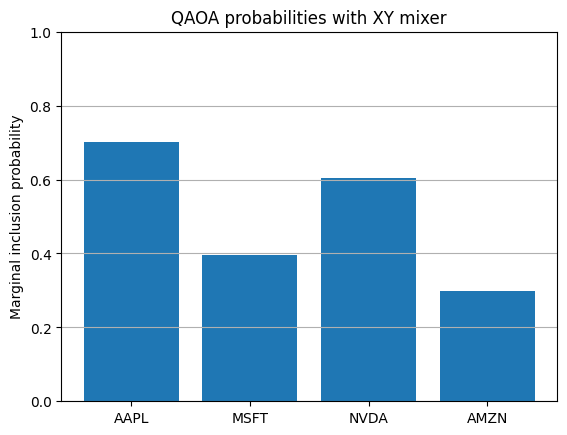

In [7]:
bar_allocations(
    tickers,
    np.array(res_xy.x_prob, dtype=float),
    ylabel="Marginal inclusion probability",
    title="QAOA probabilities with XY mixer",
    ylim=(0.0, 1.0),
    outpath=OUTDIR / "QAOA_XY_Probabilities_Real_Example_03.png",
)
plt.show()

## Final Top-K selections

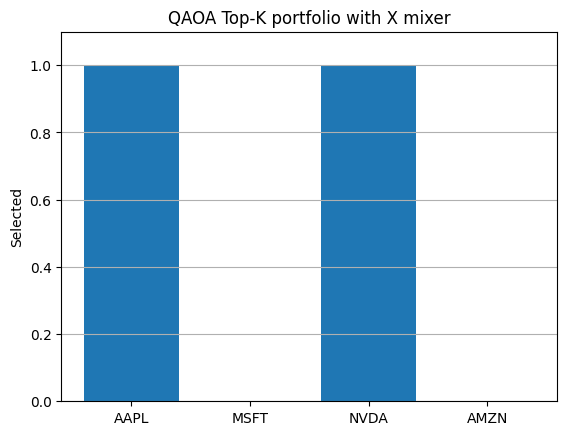

In [8]:
bar_allocations(
    tickers,
    np.array(res_x.x_topk, dtype=int),
    ylabel="Selected",
    title="QAOA Top-K portfolio with X mixer",
    ylim=(0.0, 1.1),
    outpath=OUTDIR / "QAOA_X_TopK_Real_Example_03.png",
)
plt.show()

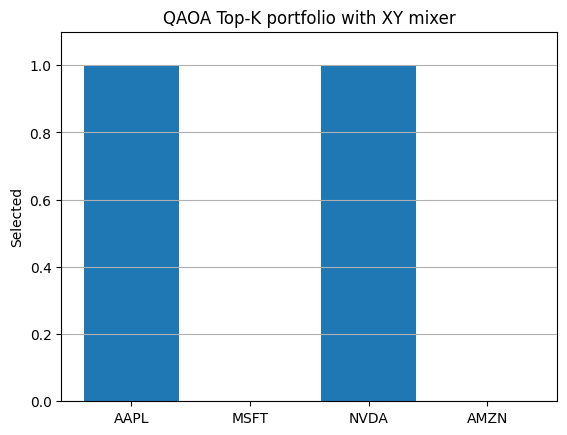

In [9]:
bar_allocations(
    tickers,
    np.array(res_xy.x_topk, dtype=int),
    ylabel="Selected",
    title="QAOA Top-K portfolio with XY mixer",
    ylim=(0.0, 1.1),
    outpath=OUTDIR / "QAOA_XY_TopK_Real_Example_03.png",
)
plt.show()